In [6]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

print("✅ TensorFlow version:", tf.__version__)


2025-10-12 12:08:08.412791: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760270888.602929      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760270888.655979      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ TensorFlow version: 2.18.0


In [7]:
datasets = [
    "/kaggle/input/fresh-and-stale-images-of-fruits-and-vegetables",
    "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset",
    "/kaggle/input/fruits-and-vegetables-dataset/Fruits_Vegetables_Dataset(12000)",
    "/kaggle/input/fresh-and-rotten-fruits-and-vegetables/Dataset/Visual_Dataset"
]

combined_dir = "/kaggle/working/combined_data"
train_dir = os.path.join(combined_dir, "train")
val_dir = os.path.join(combined_dir, "val")

for split in [train_dir, val_dir]:
    for cls in ["fresh", "rotten"]:
        os.makedirs(os.path.join(split, cls), exist_ok=True)


In [8]:
def merge_datasets():
    all_images = []
    keywords_fresh = ["fresh"]
    keywords_rotten = ["rotten", "stale"]

    for dataset in datasets:
        for root, dirs, files in os.walk(dataset):
            for folder in dirs:
                folder_path = os.path.join(root, folder)

                # Classify folders by keyword
                if any(k in folder.lower() for k in keywords_fresh):
                    label = "fresh"
                elif any(k in folder.lower() for k in keywords_rotten):
                    label = "rotten"
                else:
                    continue  # skip irrelevant folders

                for img in os.listdir(folder_path):
                    img_path = os.path.join(folder_path, img)
                    if img_path.lower().endswith((".jpg", ".png", ".jpeg")):
                        all_images.append((img_path, label))

    print(f"Total detected images: {len(all_images)}")

    # Shuffle & split
    random.shuffle(all_images)
    train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)

    for img_path, cls in train_imgs:
        shutil.copy(img_path, os.path.join(train_dir, cls))
    for img_path, cls in val_imgs:
        shutil.copy(img_path, os.path.join(val_dir, cls))

    print(f"✅ Merged {len(train_imgs)} training and {len(val_imgs)} validation images")

merge_datasets()


Total detected images: 65815
✅ Merged 52652 training and 13163 validation images


In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 32360 images belonging to 2 classes.
Found 11692 images belonging to 2 classes.


In [10]:
base_model = MobileNetV2(
    weights="/kaggle/input/freshness/tensorflow2/default/1/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
preds = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=preds)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


I0000 00:00:1760271265.024340      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
!ls /kaggle/input/freshness/tensorflow2/default/1/



mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5


In [18]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

loss, acc = model.evaluate(val_gen)
print(f"✅ Validation Accuracy: {acc*100:.2f}%")

model.save("/kaggle/working/food_freshness_detector.h5")
print("✅ Model saved as food_freshness_detector.h5")


Epoch 1/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 437s 432ms/step - accuracy: 0.9701 - loss: 0.0784 - val_accuracy: 0.9832 - val_loss: 0.0453
Epoch 2/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 440s 435ms/step - accuracy: 0.9714 - loss: 0.0728 - val_accuracy: 0.9873 - val_loss: 0.0358
Epoch 3/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 441s 436ms/step - accuracy: 0.9731 - loss: 0.0696 - val_accuracy: 0.9864 - val_loss: 0.0409
Epoch 4/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 438s 432ms/step - accuracy: 0.9730 - loss: 0.0687 - val_accuracy: 0.9875 - val_loss: 0.0384
Epoch 5/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 442s 436ms/step - accuracy: 0.9716 - loss: 0.0747 - val_accuracy: 0.9880 - val_loss: 0.0367
Epoch 6/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 441s 436ms/step - accuracy: 0.9768 - loss: 0.0649 - val_accuracy: 0.9895 - val_loss: 0.0346
Epoch 7/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 440s 435ms/step - accuracy: 0.9772 - loss: 0.0572 - val_accuracy: 0.9887 - val_loss: 0.0334
Epoch 8/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 441s 436ms/step - ac

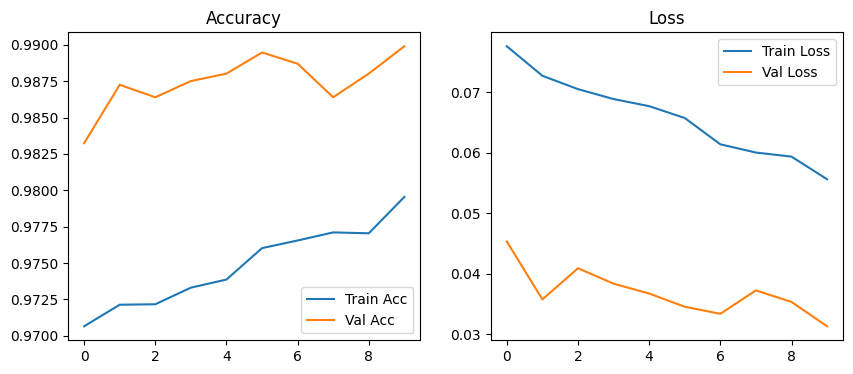

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")

plt.show()


In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)[0][0]
    label = "Fresh" if prediction < 0.5 else "Rotten"
    print(f"🧾 Prediction: {label} (score={prediction:.4f})")

test_img_path = val_gen.filepaths[0]
predict_image(test_img_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
🧾 Prediction: Fresh (score=0.0187)


In [10]:
!ls /kaggle/input/foodfreshness/keras/default/1


food_freshness_detector.h5


In [2]:
from tensorflow.keras.models import load_model

# Load the saved model (update the path if needed)
model = load_model('/kaggle/input/foodfreshness/keras/default/1/food_freshness_detector.h5')

# Confirm load success
model.summary()


2025-10-19 17:40:05.389237: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,083 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


/tmp/ipykernel_37/917701068.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Prediction: {predicted_class} (score={float(prediction):.4f})")


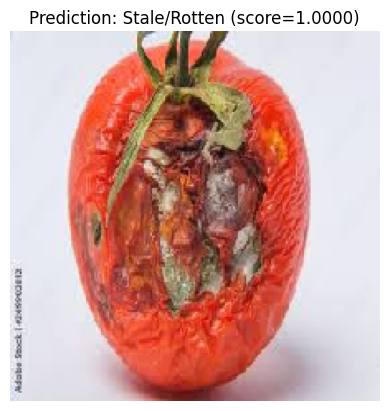

In [4]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Path to your uploaded image
img_path = '/kaggle/input/dataset1/tomato.jpeg'  # 👈 change filename if needed

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  # same normalization as training

# Make prediction
prediction = model.predict(img_array)
predicted_class = 'Fresh' if prediction < 0.5 else 'Stale/Rotten'

# Show the image and result
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {predicted_class} (score={float(prediction):.4f})")
plt.show()


In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from PIL import Image

# Load your trained model
model = load_model("/kaggle/input/foodfreshness/keras/default/1/food_freshness_detector.h5")

# Define class names based on your dataset
CLASS_NAMES = ["Fresh", "Medium Fresh", "Rotten"]

# Preprocess function
def preprocess_image(img):
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# Prediction function
def predict_freshness(img):
    img_array = preprocess_image(img)
    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)
    confidence = np.max(prediction)
    return {CLASS_NAMES[class_idx]: float(confidence)}

# Gradio interface
demo = gr.Interface(
    fn=predict_freshness,
    inputs=gr.Image(type="pil", label="Upload Food Image"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="🥗 AI-Based Food Freshness Detector",
    description="Upload an image of a food item and let the AI predict whether it's Fresh, Medium Fresh, or Rotten.",
    theme="default"
)

# Run inside Kaggle
demo.launch(share=True, inline=True, debug=True)


* Running on local URL:  http://127.0.0.1:7861

Could not create share link. Missing file: /root/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64
2. Rename the downloaded file to: frpc_linux_amd64_v0.3
3. Move the file to this location: /root/.cache/huggingface/gradio/frpc
